# `toxpol.datagen` — Synthetic Data Generation Demo

Polarized Trees needs datasets where the ground truth is *known* — which demographic dimensions drive disagreement, and how strongly. Real annotation data can't provide this, so we generate synthetic datasets with **injected, controlled polarization**.

Each text is independently assigned a **severity tier**:
- **High** — strong, non-overlapping toxic/civil split
- **Moderate** — same mechanism, softer/overlapping split
- **Low** — little to no polarization (mostly a true negative control)

This notebook walks through every public method on `AnnotatorPool`, in order.

**Requires:** `pip install "toxpol-nlp[ndfu]"`

In [1]:
import matplotlib.pyplot as plt

from toxpol.datagen import AnnotatorPool, DEFAULT_DIMENSIONS

## 1. Build the annotator pool

`DEFAULT_DIMENSIONS` covers gender, politics, age, education, and orientation.
Pass a custom dict to use different dimensions or values.
Use `exclude` to drop dimensions for ablation runs.

In [2]:
pool = AnnotatorPool(
    dimensions=DEFAULT_DIMENSIONS,
    scale=5,                        # mandatory -- Moderate/Low ranges are derived from it
    toxic_range=(4, 5),              # mandatory -- toxic pole range for the High tier
    civil_range=(1, 2),              # mandatory -- civil pole range for the High tier
    neutral_range=(3, 3),            # mandatory -- reserved for future use
    exclude=None,                  # drop dimension names, e.g. ["education"]
    annotators_per_identity=10,    # annotators replicated per unique identity
)
pool.summary()

Active dimensions : ['gender', 'politics', 'age', 'education', 'orientation']
Unique identities : 162
Annotators/identity: 10
Pool size          : 1620
Rating scale       : 1-5
  toxic_range          (high)     : (4, 5)
  civil_range          (high)     : (1, 2)
  neutral_range                   : (3, 3)
  toxic_range          (moderate) : (4, 5)
  civil_range          (moderate) : (1, 3)
  toxic_range          (low)      : (3, 5)
  civil_range          (low)      : (1, 3)


### Moderate and Low ranges are derived automatically

You only specify `toxic_range`/`civil_range` once, for the High tier. The Moderate and Low tiers' ranges are derived in `__init__` from those, shifted toward the center proportionally to `scale` -- no extra parameters needed, and they scale correctly for any `scale` you choose.

In [3]:
print("High    toxic/civil:", pool.toxic_range, pool.civil_range)
print("Moderate toxic/civil:", pool.moderate_toxic_range, pool.moderate_civil_range)
print("Low      toxic/civil:", pool.low_toxic_range, pool.low_civil_range)

High    toxic/civil: (4, 5) (1, 2)
Moderate toxic/civil: (4, 5) (1, 3)
Low      toxic/civil: (3, 5) (1, 3)


## 2. Generate a dataset

Every text is an **independent draw**: its severity tier, and (for High/Moderate/weighted-Low texts) its own random bias config, are generated fresh per text.

In [4]:
dataset, bias_configs = pool.generate_dataset(
    n_texts=10,
    n_annotators_per_text=100,     # must be <= pool.pool_size (1620)
    noise=0.05,                     # prob. of fully random rating (outlier noise)
    high_ratio=0.60,                # share of texts with strong polarization
    moderate_ratio=0.20,            # share with a softer signal
    low_ratio=0.20,                 # share with little to no polarization
    low_unimodal_share=0.40,        # within Low, fraction with no demographic split
)

print(dataset.head(10))
print("\nTier for each text:")
for text_id, cfg in bias_configs.items():
    print(f"  text {text_id}: {cfg['tier']}" + (f" ({cfg['subcase']})" if cfg.get("subcase") else ""))

   text_id  annotator_id      gender politics    age education   orientation  \
0        0          1545  non-binary    right  25-50      high  heterosexual   
1        0           941      female    right    <25      high  heterosexual   
2        0          1178  non-binary     left  25-50    medium        lgbtq+   
3        0           395        male    right    <25    medium        lgbtq+   
4        0          1555  non-binary    right  25-50      high        lgbtq+   
5        0           415        male    right    <25      high        lgbtq+   
6        0          1411  non-binary   center    >50    medium        lgbtq+   
7        0          1402  non-binary   center    >50    medium  heterosexual   
8        0           512        male    right    >50    medium        lgbtq+   
9        0           997      female    right  25-50    medium        lgbtq+   

   rating  
0       1  
1       1  
2       4  
3       5  
4       5  
5       5  
6       4  
7       1  
8       2  

## 3. Inspect each text's bias config

`describe_bias` prints the per-dimension weights (for High/Moderate/weighted-Low texts) or the unimodal peak/spread (for true-unimodal Low texts).

In [5]:
# Show one example of each tier that appears in this dataset
seen = set()
for text_id, cfg in bias_configs.items():
    if cfg["tier"] not in seen:
        seen.add(cfg["tier"])
        pool.describe_bias(bias_configs, text_id=text_id)
        print()

Text 0 -- tier: high
  threshold (median combined weight): 1.105
  gender       male=1.17  female=0.62  non-binary=1.13
  politics     left=1.70  center=1.08  right=0.58
  age          <25=1.39  25-50=1.23  >50=0.55
  education    low=0.54  medium=1.37  high=1.49
  orientation  heterosexual=1.33  lgbtq+=1.89

Text 2 -- tier: low (weighted)
  threshold (median combined weight): 1.177
  gender       male=1.87  female=0.53  non-binary=1.09
  politics     left=1.13  center=1.73  right=1.76
  age          <25=0.80  25-50=0.83  >50=1.13
  education    low=0.63  medium=1.47  high=1.50
  orientation  heterosexual=1.25  lgbtq+=1.61



## 4. Per-text nDFU

`summarize` reports the nDFU for one text, broken down by every dimension value.

In [6]:
pool.summarize(dataset, bias_configs, text_id=0)

Text 0 (tier: high) -- overall nDFU: 0.667

gender:
  female: 0.200
  male: 0.500
  non-binary: 0.200

politics:
  center: 0.778
  left: 0.091
  right: 0.467

age:
  25-50: 0.455
  <25: 0.263
  >50: 0.182

education:
  high: 0.455
  low: 0.000
  medium: 0.133

orientation:
  heterosexual: 0.818
  lgbtq+: 0.471



## 5. Raw nDFU scores

`analyze` returns the same scores `summarize`/`summarize_all` use internally, as a plain dict — useful if you want to feed them into your own analysis instead of printing.

In [7]:
results = pool.analyze(dataset, bias_configs)
print("Overall nDFU for text 0:", results[0]["overall"])
print("Per-value nDFU for 'gender' on text 0:", results[0]["gender"])

Overall nDFU for text 0: 0.6666666666666666
Per-value nDFU for 'gender' on text 0: {'female': 0.2, 'male': 0.5, 'non-binary': 0.19999999999999996}


## 6. Dataset-wide summary

`summarize_all` reports overall nDFU plus a per-tier and per-dimension breakdown across the whole dataset — High should sit much higher than Moderate, which should sit above Low.

In [8]:
pool.summarize_all(dataset, bias_configs)

Overall nDFU -- mean: 0.667  median: 0.737  (across 10 texts)

Tier counts: {'high': 9, 'low': 1}

high       mean: 0.738  min: 0.533  max: 0.964  (n=9)
low        mean: 0.029  min: 0.029  max: 0.029  (n=1)


gender:
  male            mean: 0.553  min: 0.222  max: 1.000
  female          mean: 0.343  min: 0.000  max: 0.889
  non-binary      mean: 0.457  min: 0.125  max: 0.769

politics:
  left            mean: 0.473  min: 0.091  max: 0.750
  center          mean: 0.445  min: 0.000  max: 0.833
  right           mean: 0.495  min: 0.000  max: 0.909

age:
  <25             mean: 0.366  min: 0.091  max: 0.750
  25-50           mean: 0.451  min: 0.000  max: 0.900
  >50             mean: 0.384  min: 0.059  max: 0.889

education:
  low             mean: 0.439  min: 0.000  max: 0.857
  medium          mean: 0.386  min: 0.000  max: 0.909
  high            mean: 0.501  min: 0.067  max: 0.900

orientation:
  heterosexual    mean: 0.456  min: 0.000  max: 0.818
  lgbtq+          mean: 0.535  min: 0.

## 7. Visualise — rating distributions for one High-tier text

For a single High-tier text, plot the rating histogram split by one dimension's values, to see the toxic/civil separation directly.

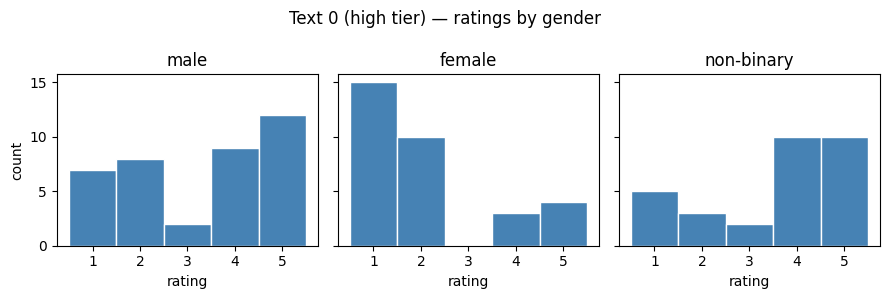

In [9]:
high_text_id = next(tid for tid, cfg in bias_configs.items() if cfg["tier"] == "high")
text_data = dataset[dataset["text_id"] == high_text_id]
scale = pool.scale
bins = range(1, scale + 2)

dim = "gender"
values = pool.active_dims[dim]

fig, axes = plt.subplots(1, len(values), figsize=(3 * len(values), 3), sharey=True)
fig.suptitle(f"Text {high_text_id} (high tier) — ratings by {dim}")

for ax, value in zip(axes, values):
    subset = text_data[text_data[dim] == value]["rating"]
    ax.hist(subset, bins=bins, align="left", color="steelblue", edgecolor="white")
    ax.set_title(value)
    ax.set_xlabel("rating")
    ax.set_xticks(range(1, scale + 1))

axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()